## Gene Fusions — `5_OmicsFusionFilteredSupplementary.csv`

One row per detected gene fusion event across ~1,699 cell lines. A fusion is where two genes get joined together — often the defining feature of a cancer type (e.g., BCR-ABL in leukaemia). Filter `IsDefaultEntryForModel == 'Yes'` before aggregating; Ensembl IDs are embedded inside the `gene1/gene2` columns and require regex to extract cleanly.

In [1]:
import __init__ as ini
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA
from scipy import stats

sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams["figure.dpi"] = 100


In [2]:
df = pd.read_csv(ini.df5)

In [3]:
df.shape

(184237, 30)

In [4]:
df.head()

,Unnamed: 0,SequencingID,ModelID,IsDefaultEntryForModel,ModelConditionID,IsDefaultEntryForMC,CanonicalFusionName,gene1(ENS ID),gene2(ENS ID),TotalReadsInSample,...,breakpoint2,site1,site2,type,coverage1,coverage2,tags,retained_protein_domains,direction1,direction2
0,0,CDS-010xbm,ACH-001113,Yes,MC-001113-k2lR,Yes,DLG1--SERPINI1,DLG1 (ENSG00000075711.21),SERPINI1 (.),47434547,...,chr3:167836645,CDS/splice-site,intergenic,inversion,1454,76,.,.,upstream,upstream
1,1,CDS-010xbm,ACH-001113,Yes,MC-001113-k2lR,Yes,ADAM17--ITGB1BP1,ADAM17 (ENSG00000151694.14),ITGB1BP1 (ENSG00000119185.13),47434547,...,chr2:9414256,CDS/splice-site,CDS/splice-site,deletion/read-through,883,724,.,.,upstream,downstream
2,2,CDS-010xbm,ACH-001113,Yes,MC-001113-k2lR,Yes,ADAM17--ITGB1BP1,ADAM17 (ENSG00000151694.14),ITGB1BP1 (ENSG00000119185.13),47434547,...,chr2:9412405,CDS/splice-site,CDS/splice-site,deletion/read-through,883,754,.,.,upstream,downstream
3,3,CDS-010xbm,ACH-001113,Yes,MC-001113-k2lR,Yes,ADAM17--ITGB1BP1,ADAM17 (ENSG00000151694.14),ITGB1BP1 (ENSG00000119185.13),47434547,...,chr2:9414256,exon/splice-site,CDS/splice-site,deletion/read-through,41,724,.,.,upstream,downstream
4,4,CDS-010xbm,ACH-001113,Yes,MC-001113-k2lR,Yes,ADAM17--ITGB1BP1,ADAM17 (ENSG00000151694.14),ITGB1BP1 (ENSG00000119185.13),47434547,...,chr2:9408205,CDS/splice-site,CDS/splice-site,deletion/read-through,883,680,.,.,upstream,downstream


In [5]:
df.drop(columns=["Unnamed: 0"], inplace=True)

In [6]:
df.head()

,SequencingID,ModelID,IsDefaultEntryForModel,ModelConditionID,IsDefaultEntryForMC,CanonicalFusionName,gene1(ENS ID),gene2(ENS ID),TotalReadsInSample,TotalReadsSupportingFusion,...,breakpoint2,site1,site2,type,coverage1,coverage2,tags,retained_protein_domains,direction1,direction2
0,CDS-010xbm,ACH-001113,Yes,MC-001113-k2lR,Yes,DLG1--SERPINI1,DLG1 (ENSG00000075711.21),SERPINI1 (.),47434547,203,...,chr3:167836645,CDS/splice-site,intergenic,inversion,1454,76,.,.,upstream,upstream
1,CDS-010xbm,ACH-001113,Yes,MC-001113-k2lR,Yes,ADAM17--ITGB1BP1,ADAM17 (ENSG00000151694.14),ITGB1BP1 (ENSG00000119185.13),47434547,138,...,chr2:9414256,CDS/splice-site,CDS/splice-site,deletion/read-through,883,724,.,.,upstream,downstream
2,CDS-010xbm,ACH-001113,Yes,MC-001113-k2lR,Yes,ADAM17--ITGB1BP1,ADAM17 (ENSG00000151694.14),ITGB1BP1 (ENSG00000119185.13),47434547,57,...,chr2:9412405,CDS/splice-site,CDS/splice-site,deletion/read-through,883,754,.,.,upstream,downstream
3,CDS-010xbm,ACH-001113,Yes,MC-001113-k2lR,Yes,ADAM17--ITGB1BP1,ADAM17 (ENSG00000151694.14),ITGB1BP1 (ENSG00000119185.13),47434547,50,...,chr2:9414256,exon/splice-site,CDS/splice-site,deletion/read-through,41,724,.,.,upstream,downstream
4,CDS-010xbm,ACH-001113,Yes,MC-001113-k2lR,Yes,ADAM17--ITGB1BP1,ADAM17 (ENSG00000151694.14),ITGB1BP1 (ENSG00000119185.13),47434547,22,...,chr2:9408205,CDS/splice-site,CDS/splice-site,deletion/read-through,883,680,.,.,upstream,downstream


In [7]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 184237 entries, 0 to 184236
Data columns (total 29 columns):
 #   Column                      Non-Null Count   Dtype  
---  ------                      --------------   -----  
 0   SequencingID                184237 non-null  str    
 1   ModelID                     184237 non-null  str    
 2   IsDefaultEntryForModel      184237 non-null  str    
 3   ModelConditionID            184237 non-null  str    
 4   IsDefaultEntryForMC         184237 non-null  str    
 5   CanonicalFusionName         184237 non-null  str    
 6   gene1(ENS ID)               184237 non-null  str    
 7   gene2(ENS ID)               184237 non-null  str    
 8   TotalReadsInSample          184237 non-null  int64  
 9   TotalReadsSupportingFusion  184237 non-null  int64  
 10  FFPM                        184237 non-null  float64
 11  confidence                  184237 non-null  str    
 12  split_reads1                184237 non-null  int64  
 13  split_reads2             

In [8]:
df["SequencingID"].nunique(), df["SequencingID"].unique()

(1754,
 <ArrowStringArray>
 ['CDS-010xbm', 'CDS-02TzJp', 'CDS-0693hw', 'CDS-07Plat', 'CDS-08FOcu',
  'CDS-09EywZ', 'CDS-0BNTL7', 'CDS-0CqPRM', 'CDS-0EOjym', 'CDS-0Jkjew',
  ...
  'CDS-zmRkou', 'CDS-zmiamL', 'CDS-zn1Rjq', 'CDS-zo9UQG', 'CDS-zqv0Ai',
  'CDS-zsS3zE', 'CDS-zsp0NA', 'CDS-zvrgDc', 'CDS-zvw4zv', 'CDS-zx92JS']
 Length: 1754, dtype: str)

In [9]:
df["ModelID"].nunique(), df["ModelID"].unique()

(1699,
 <ArrowStringArray>
 ['ACH-001113', 'ACH-001289', 'ACH-001339', 'ACH-001619', 'ACH-001979',
  'ACH-002438', 'ACH-001538', 'ACH-000242', 'ACH-000708', 'ACH-000327',
  ...
  'ACH-000036', 'ACH-000973', 'ACH-001128', 'ACH-003437', 'ACH-000750',
  'ACH-000285', 'ACH-002669', 'ACH-001997', 'ACH-003297', 'ACH-000052']
 Length: 1699, dtype: str)

In [10]:
# 1. Create a simplified dataframe with just the unique pairs
unique_pairs = df[['SequencingID', 'ModelID']].drop_duplicates()

# 2. Count how many unique 'Gene' IDs exist for each 'Gene nam'
name_counts = unique_pairs.groupby('SequencingID')['ModelID'].transform('nunique')

# 3. Filter for Gene names that have more than 1 Ensembl ID associated with them
duplicated_names_df = unique_pairs[name_counts > 1].sort_values(by='SequencingID')

duplicated_names_df

,SequencingID,ModelID


In [11]:
print(df.head())

  SequencingID     ModelID IsDefaultEntryForModel ModelConditionID  \
0   CDS-010xbm  ACH-001113                    Yes   MC-001113-k2lR   
1   CDS-010xbm  ACH-001113                    Yes   MC-001113-k2lR   
2   CDS-010xbm  ACH-001113                    Yes   MC-001113-k2lR   
3   CDS-010xbm  ACH-001113                    Yes   MC-001113-k2lR   
4   CDS-010xbm  ACH-001113                    Yes   MC-001113-k2lR   

  IsDefaultEntryForMC CanonicalFusionName                gene1(ENS ID)  \
0                 Yes      DLG1--SERPINI1    DLG1 (ENSG00000075711.21)   
1                 Yes    ADAM17--ITGB1BP1  ADAM17 (ENSG00000151694.14)   
2                 Yes    ADAM17--ITGB1BP1  ADAM17 (ENSG00000151694.14)   
3                 Yes    ADAM17--ITGB1BP1  ADAM17 (ENSG00000151694.14)   
4                 Yes    ADAM17--ITGB1BP1  ADAM17 (ENSG00000151694.14)   

                   gene2(ENS ID)  TotalReadsInSample  \
0                   SERPINI1 (.)            47434547   
1  ITGB1BP1 (ENSG00000

In [12]:
df.loc[0]

SequencingID                                 CDS-010xbm
ModelID                                      ACH-001113
IsDefaultEntryForModel                              Yes
ModelConditionID                         MC-001113-k2lR
IsDefaultEntryForMC                                 Yes
CanonicalFusionName                      DLG1--SERPINI1
gene1(ENS ID)                 DLG1 (ENSG00000075711.21)
gene2(ENS ID)                              SERPINI1 (.)
TotalReadsInSample                             47434547
TotalReadsSupportingFusion                          203
FFPM                                           4.279581
confidence                                         high
split_reads1                                          6
split_reads2                                         12
discordant_mates                                    185
strand1(gene/fusion)                                -/-
strand2(gene/fusion)                                ./+
reading_frame                              out-o

In [13]:
# 1. Extract the base Ensembl ID (e.g., "ENSG00000075711")
# Regex looks for "ENSG" followed by one or more digits (\d+)
df['ens1'] = df['gene1(ENS ID)'].str.extract(r'(ENSG\d+)')
df['ens2'] = df['gene2(ENS ID)'].str.extract(r'(ENSG\d+)')

# 2. Extract the version digits after the decimal (e.g., "21")
# Regex looks for the ENSG pattern, a literal dot (\.), and captures the digits after it
df['decimal_digit1'] = df['gene1(ENS ID)'].str.extract(r'ENSG\d+\.(\d+)')
df['decimal_digit2'] = df['gene2(ENS ID)'].str.extract(r'ENSG\d+\.(\d+)')

df['gene1'] = df['gene1(ENS ID)'].str.extract(r'^([^ (]+)')
df['gene2'] = df['gene2(ENS ID)'].str.extract(r'^([^ (]+)')

In [14]:
df.loc[0]

SequencingID                                 CDS-010xbm
ModelID                                      ACH-001113
IsDefaultEntryForModel                              Yes
ModelConditionID                         MC-001113-k2lR
IsDefaultEntryForMC                                 Yes
CanonicalFusionName                      DLG1--SERPINI1
gene1(ENS ID)                 DLG1 (ENSG00000075711.21)
gene2(ENS ID)                              SERPINI1 (.)
TotalReadsInSample                             47434547
TotalReadsSupportingFusion                          203
FFPM                                           4.279581
confidence                                         high
split_reads1                                          6
split_reads2                                         12
discordant_mates                                    185
strand1(gene/fusion)                                -/-
strand2(gene/fusion)                                ./+
reading_frame                              out-o

In [15]:
df.head()

,SequencingID,ModelID,IsDefaultEntryForModel,ModelConditionID,IsDefaultEntryForMC,CanonicalFusionName,gene1(ENS ID),gene2(ENS ID),TotalReadsInSample,TotalReadsSupportingFusion,...,tags,retained_protein_domains,direction1,direction2,ens1,ens2,decimal_digit1,decimal_digit2,gene1,gene2
0,CDS-010xbm,ACH-001113,Yes,MC-001113-k2lR,Yes,DLG1--SERPINI1,DLG1 (ENSG00000075711.21),SERPINI1 (.),47434547,203,...,.,.,upstream,upstream,ENSG00000075711,NaN,21,NaN,DLG1,SERPINI1
1,CDS-010xbm,ACH-001113,Yes,MC-001113-k2lR,Yes,ADAM17--ITGB1BP1,ADAM17 (ENSG00000151694.14),ITGB1BP1 (ENSG00000119185.13),47434547,138,...,.,.,upstream,downstream,ENSG00000151694,ENSG00000119185,14,13,ADAM17,ITGB1BP1
2,CDS-010xbm,ACH-001113,Yes,MC-001113-k2lR,Yes,ADAM17--ITGB1BP1,ADAM17 (ENSG00000151694.14),ITGB1BP1 (ENSG00000119185.13),47434547,57,...,.,.,upstream,downstream,ENSG00000151694,ENSG00000119185,14,13,ADAM17,ITGB1BP1
3,CDS-010xbm,ACH-001113,Yes,MC-001113-k2lR,Yes,ADAM17--ITGB1BP1,ADAM17 (ENSG00000151694.14),ITGB1BP1 (ENSG00000119185.13),47434547,50,...,.,.,upstream,downstream,ENSG00000151694,ENSG00000119185,14,13,ADAM17,ITGB1BP1
4,CDS-010xbm,ACH-001113,Yes,MC-001113-k2lR,Yes,ADAM17--ITGB1BP1,ADAM17 (ENSG00000151694.14),ITGB1BP1 (ENSG00000119185.13),47434547,22,...,.,.,upstream,downstream,ENSG00000151694,ENSG00000119185,14,13,ADAM17,ITGB1BP1


### Filter to default entries & re-check shape
Each cell line may have multiple sequencing runs; `IsDefaultEntryForModel=='Yes'` keeps the canonical one.

In [16]:
df_def = df[df["IsDefaultEntryForModel"] == "Yes"].copy()
print(f"All fusion rows   : {len(df)}")
print(f"Default-only rows : {len(df_def)}")
print(f"Unique ModelIDs   : {df_def['ModelID'].nunique()}")


All fusion rows   : 184237
Default-only rows : 178041
Unique ModelIDs   : 1699


### Fusion burden per cell line
Most cancer cell lines have a handful of fusions; a very high count signals genomic chaos.

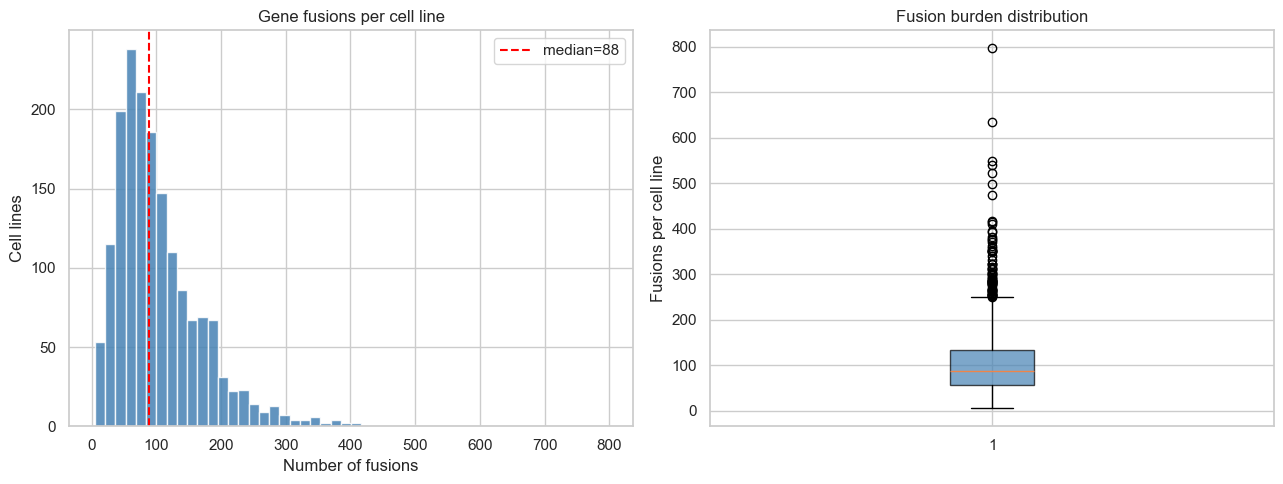

In [17]:
fusions_per_model = df_def.groupby("ModelID").size()

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
axes[0].hist(fusions_per_model, bins=50, color="steelblue", edgecolor="white", alpha=0.85)
axes[0].set_title("Gene fusions per cell line")
axes[0].set_xlabel("Number of fusions"); axes[0].set_ylabel("Cell lines")
axes[0].axvline(fusions_per_model.median(), color="red", linestyle="--",
                label=f"median={fusions_per_model.median():.0f}")
axes[0].legend()

axes[1].boxplot(fusions_per_model, vert=True, patch_artist=True,
                boxprops=dict(facecolor="steelblue", alpha=0.7))
axes[1].set_title("Fusion burden distribution")
axes[1].set_ylabel("Fusions per cell line")

plt.tight_layout(); plt.show()


### Top 30 most common fusions
Recurring fusions across many cell lines are clinically significant (e.g., BCR-ABL, EML4-ALK).

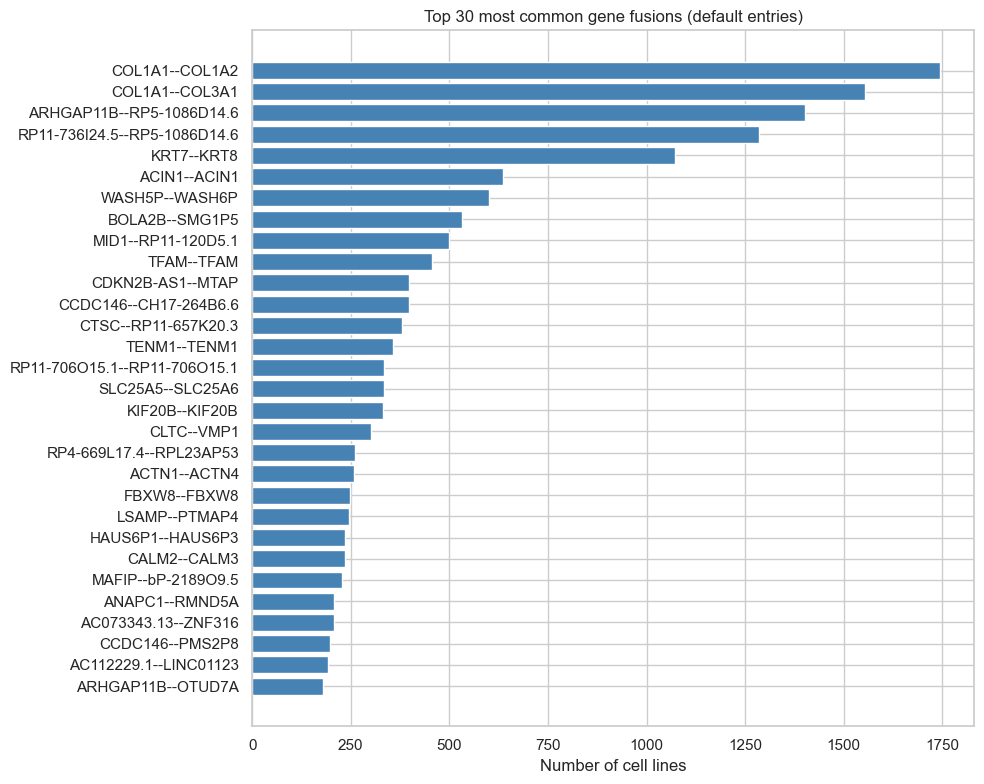

In [18]:
top_fusions = df_def["CanonicalFusionName"].value_counts().head(30)

fig, ax = plt.subplots(figsize=(10, 8))
ax.barh(top_fusions.index[::-1], top_fusions.values[::-1], color="steelblue")
ax.set_title("Top 30 most common gene fusions (default entries)")
ax.set_xlabel("Number of cell lines")
plt.tight_layout(); plt.show()


### Confidence, fusion type, and reading frame
High-confidence, in-frame fusions are the most likely to produce functional fusion proteins.

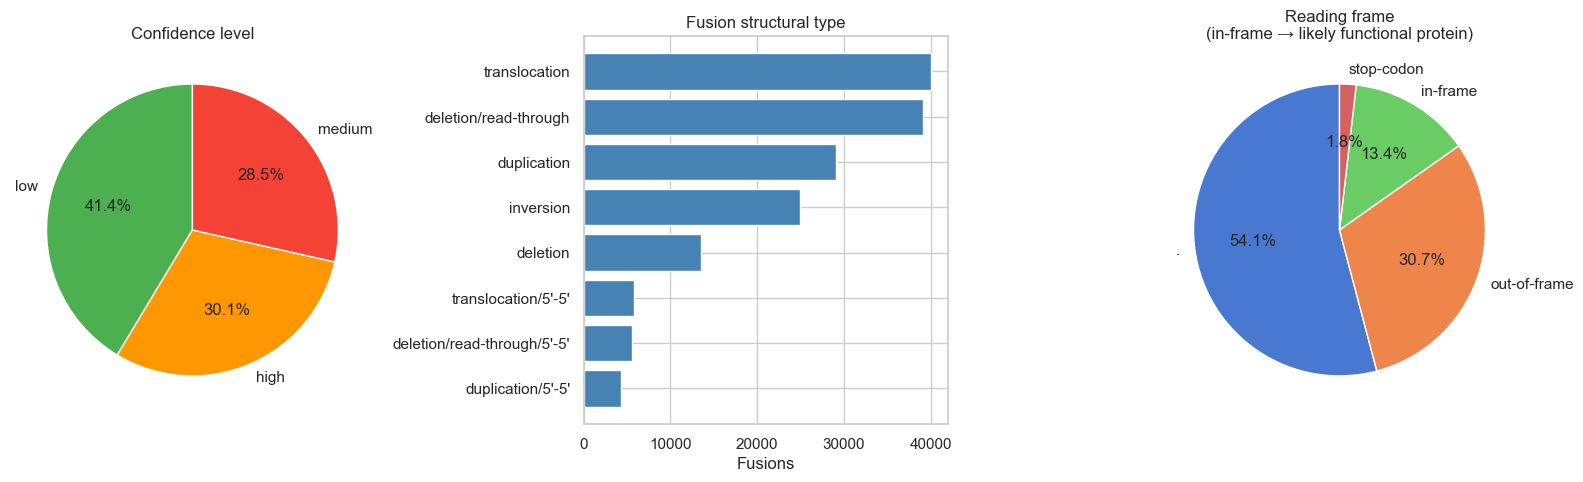

In [19]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

conf = df_def["confidence"].value_counts()
axes[0].pie(conf.values, labels=conf.index, autopct="%1.1f%%", startangle=90,
            colors=["#4CAF50", "#FF9800", "#F44336"])
axes[0].set_title("Confidence level")

ftype = df_def["type"].value_counts().head(8)
axes[1].barh(ftype.index[::-1], ftype.values[::-1], color="steelblue")
axes[1].set_title("Fusion structural type")
axes[1].set_xlabel("Fusions")

rf = df_def["reading_frame"].value_counts()
axes[2].pie(rf.values, labels=rf.index, autopct="%1.1f%%", startangle=90)
axes[2].set_title("Reading frame\n(in-frame → likely functional protein)")

plt.tight_layout(); plt.show()


### FFPM distribution
FFPM (fusion fragments per million reads) measures how strongly a fusion is expressed. Very low FFPM may be noise.

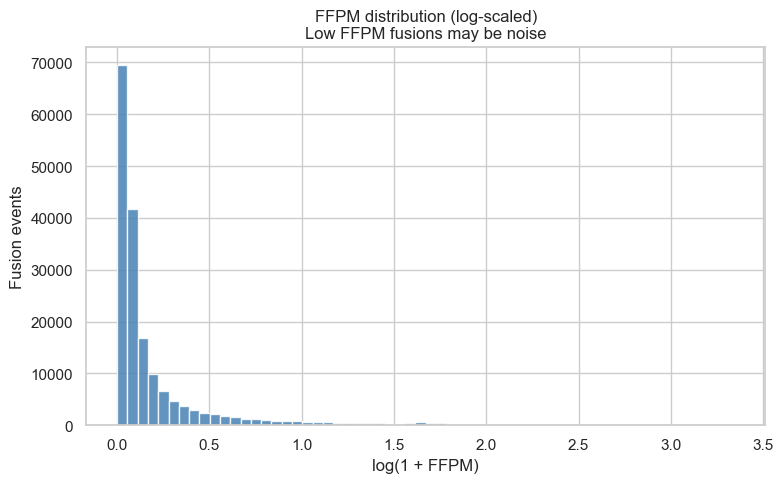

In [20]:
fig, ax = plt.subplots(figsize=(8, 5))
ax.hist(np.log1p(df_def["FFPM"]), bins=60, color="steelblue", edgecolor="white", alpha=0.85)
ax.set_xlabel("log(1 + FFPM)"); ax.set_ylabel("Fusion events")
ax.set_title("FFPM distribution (log-scaled)\nLow FFPM fusions may be noise")
plt.tight_layout(); plt.show()


### Top 20 most frequently fused genes
Genes that appear as fusion partners across many cell lines may be structural hotspots.

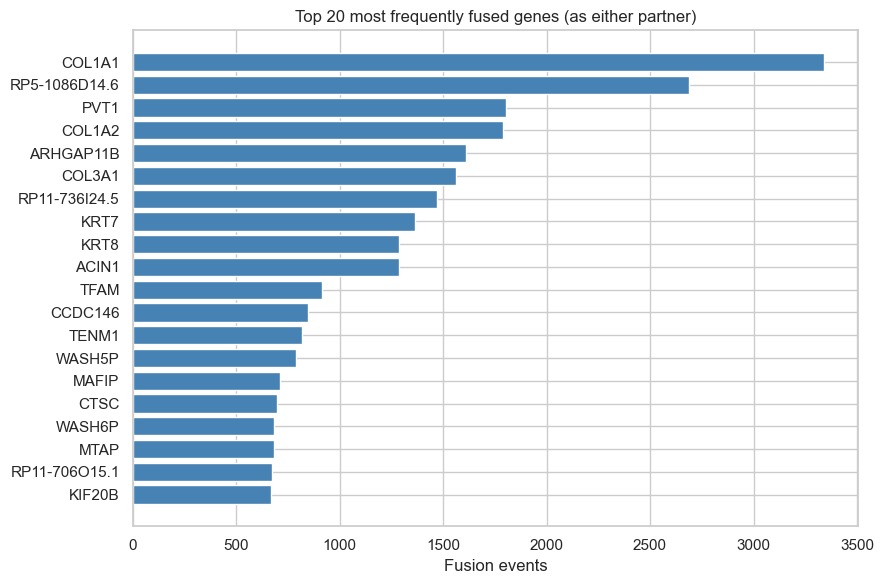

In [21]:
import re
gene1 = df_def["gene1(ENS ID)"].str.extract(r"^([^ (]+)").iloc[:, 0]
gene2 = df_def["gene2(ENS ID)"].str.extract(r"^([^ (]+)").iloc[:, 0]
all_genes = pd.concat([gene1, gene2]).value_counts().head(20)

fig, ax = plt.subplots(figsize=(9, 6))
ax.barh(all_genes.index[::-1], all_genes.values[::-1], color="steelblue")
ax.set_title("Top 20 most frequently fused genes (as either partner)")
ax.set_xlabel("Fusion events")
plt.tight_layout(); plt.show()


### Key findings

In [22]:
print("=== Gene Fusions ===")
print(f"Total fusion events (all)     : {len(df)}")
print(f"Default-entry events          : {len(df_def)}")
print(f"Cell lines with any fusion    : {df_def['ModelID'].nunique()}")
print(f"Median fusions per line       : {fusions_per_model.median():.0f}")
print(f"High-confidence fusions       : {(df_def.confidence=='high').sum()} ({(df_def.confidence=='high').mean()*100:.1f}%)")
print(f"In-frame fusions              : {(df_def.reading_frame=='in-frame').sum()} ({(df_def.reading_frame=='in-frame').mean()*100:.1f}%)")


=== Gene Fusions ===
Total fusion events (all)     : 184237
Default-entry events          : 178041
Cell lines with any fusion    : 1699
Median fusions per line       : 88
High-confidence fusions       : 53583 (30.1%)
In-frame fusions              : 23838 (13.4%)


## Join Analysis — how this table connects to the others

df5 uses **ModelID** directly — a single-hop join to df9. It also links naturally
to df6 (mutations) and df2 (RNA expression) via the shared ModelID key.

| From | Key column | To | Key column | Cardinality | Notes |
|---|---|---|---|---|---|
| df5 | `ModelID` | df9 | `DepMap_ID` | many:1 | multiple fusions per line |
| df5 | `ModelID` | df2 via df8 | ModelID | many:1 | fusions + RNA expression |
| df5 | `ModelID` | df6 via df8 | ModelID | many:many | fusions + mutations per line |
| df5 | `ModelID` | df14 | `ModelID` | many:1 | fusions + genome instability |

**Biological note:** Fusions are rare events. Most cell lines have 0–50 fusions.
Joining to mutations (df6) lets us ask: does a cell line with a specific fusion
also carry complementary driver mutations? This co-occurrence is clinically important.


In [23]:
# ── A/B: Join coverage df5 → df9 and cross-dataset overlaps ─────────────────
df9_ids  = pd.read_csv(ini.df9, usecols=["DepMap_ID", "lineage"])
df8_ids  = pd.read_csv(ini.df8, usecols=["ProfileID", "ModelID", "Datatype"])

fusion_models = set(df["ModelID"].dropna().unique())    # df still has ModelID column
df9_models    = set(df9_ids["DepMap_ID"].dropna())
matched       = fusion_models & df9_models
lost_fusions  = fusion_models - df9_models

# Models with mutation data (df6 ProfileIDs → ModelIDs via df8)
df6_profiles = set(pd.read_csv(ini.df6, usecols=["ProfileID"])["ProfileID"].dropna())
df8_wes      = df8_ids[df8_ids["Datatype"].isin(["wes","wgs"])]
mut_models   = set(df8_wes[df8_wes["ProfileID"].isin(df6_profiles)]["ModelID"])

# Models with RNA data
rna_models = set(df8_ids[df8_ids["Datatype"]=="rna"]["ModelID"])

print("=== df5 join: ModelID → df9 ===")
print(f"Unique ModelIDs in df5         : {len(fusion_models)}")
print(f"Matched in df9                 : {len(matched)} ({len(matched)/len(fusion_models)*100:.1f}%)")
print(f"Lost (not in df9)              : {len(lost_fusions)}")
print()
print(f"df5 models also with RNA (df2) : {len(matched & rna_models)}")
print(f"df5 models also with mut (df6) : {len(matched & mut_models)}")
print(f"Triple overlap (RNA+Fus+Mut)   : {len(matched & rna_models & mut_models)}")
df14_m = set(pd.read_csv(ini.df14, usecols=["ModelID"])["ModelID"].dropna())
print(f"df5 models also in df14 (sigs) : {len(matched & df14_m)}")


=== df5 join: ModelID → df9 ===
Unique ModelIDs in df5         : 1699
Matched in df9                 : 1428 (84.0%)
Lost (not in df9)              : 271

df5 models also with RNA (df2) : 1411
df5 models also with mut (df6) : 1379
Triple overlap (RNA+Fus+Mut)   : 1364
df5 models also in df14 (sigs) : 1386


In [24]:
# ── C: Format check on ModelID in df5 ───────────────────────────────────────
def fmt_check(series, name, prefix=None):
    s = series.dropna().astype(str)
    print(f"Format check — {name} (n={len(s)} non-null, {series.isna().sum()} NaN):")
    print(f"  Leading whitespace  : {s.str.startswith(' ').any()}")
    print(f"  Trailing whitespace : {s.str.endswith(' ').any()}")
    if prefix:
        ok = s.str.startswith(prefix).all()
        print(f"  All start '{prefix}'  : {ok}")
        if not ok:
            print(f"  Non-prefix examples : {s[~s.str.startswith(prefix)].head(3).tolist()}")
    lens = s.str.len()
    print(f"  Length range        : {lens.min()} – {lens.max()}")
    dups = series.duplicated().sum()
    print(f"  Duplicates          : {dups}")


fmt_check(df["ModelID"].dropna(), "ModelID (df5)", prefix="ACH-")
print()
# SequencingID format check
fmt_check(df["SequencingID"].dropna(), "SequencingID (df5)", prefix="CDS-")


Format check — ModelID (df5) (n=184237 non-null, 0 NaN):
  Leading whitespace  : False
  Trailing whitespace : False
  All start 'ACH-'  : True
  Length range        : 10 – 10
  Duplicates          : 182538

Format check — SequencingID (df5) (n=184237 non-null, 0 NaN):
  Leading whitespace  : False
  Trailing whitespace : False
  All start 'CDS-'  : True
  Length range        : 10 – 10
  Duplicates          : 182483


### Biological implications

Cell lines with fusions that are NOT in df9 cannot be annotated with cancer type —
they represent legacy or non-standard DepMap entries. These rows should typically
be dropped before modelling.

The triple overlap (RNA + fusions + mutations) is the richest training set. Lines
with fusions but no mutation data may have incomplete genomic characterisation.


In [25]:
# Biological: lineage breakdown of fused vs non-fused cell lines in df9
fused_in_df9     = df9_ids[df9_ids["DepMap_ID"].isin(matched)]
not_fused_in_df9 = df9_ids[~df9_ids["DepMap_ID"].isin(fusion_models)]

print("Lineages of cell lines WITH fusion data (top 10):")
print(fused_in_df9["lineage"].value_counts().head(10).to_string())
print()
print("Lineages of df9 lines WITHOUT any fusion data (top 10):")
print(not_fused_in_df9["lineage"].value_counts().head(10).to_string())
print()
# Coverage fraction per lineage
total_per = df9_ids["lineage"].value_counts()
fused_per = fused_in_df9["lineage"].value_counts()
pct = (fused_per / total_per * 100).dropna().sort_values()
print("Fusion coverage % per lineage (lowest first):")
print(pct.head(10).round(1).to_string())


Lineages of cell lines WITH fusion data (top 10):
lineage
lung                      213
blood                     105
skin                       87
lymphocyte                 86
central_nervous_system     86
colorectal                 73
ovary                      65
breast                     64
soft_tissue                62
upper_aerodigestive        58

Lineages of df9 lines WITHOUT any fusion data (top 10):
lineage
lung                      61
unknown                   44
bone                      36
blood                     36
skin                      33
lymphocyte                24
central_nervous_system    23
breast                    22
kidney                    21
upper_aerodigestive       21

Fusion coverage % per lineage (lowest first):
lineage
unknown                       6.4
bone                         54.4
kidney                       65.0
peripheral_nervous_system    70.6
skin                         72.5
upper_aerodigestive          73.4
breast                      

## Join Analysis — how this table connects to the others

df5 uses **ModelID** directly — a single-hop join to df9. It also links naturally
to df6 (mutations) and df2 (RNA expression) via the shared ModelID key.

| From | Key column | To | Key column | Cardinality | Notes |
|---|---|---|---|---|---|
| df5 | `ModelID` | df9 | `DepMap_ID` | many:1 | multiple fusions per line |
| df5 | `ModelID` | df2 via df8 | ModelID | many:1 | fusions + RNA expression |
| df5 | `ModelID` | df6 via df8 | ModelID | many:many | fusions + mutations per line |
| df5 | `ModelID` | df14 | `ModelID` | many:1 | fusions + genome instability |

**Biological note:** Fusions are rare events. Most cell lines have 0–50 fusions.
Joining to mutations (df6) lets us ask: does a cell line with a specific fusion
also carry complementary driver mutations? This co-occurrence is clinically important.


In [26]:
# ── A/B: Join coverage df5 → df9 and cross-dataset overlaps ─────────────────
df9_ids  = pd.read_csv(ini.df9, usecols=["DepMap_ID", "lineage"])
df8_ids  = pd.read_csv(ini.df8, usecols=["ProfileID", "ModelID", "Datatype"])

fusion_models = set(df["ModelID"].dropna().unique())    # df still has ModelID column
df9_models    = set(df9_ids["DepMap_ID"].dropna())
matched       = fusion_models & df9_models
lost_fusions  = fusion_models - df9_models

# Models with mutation data (df6 ProfileIDs → ModelIDs via df8)
df6_profiles = set(pd.read_csv(ini.df6, usecols=["ProfileID"])["ProfileID"].dropna())
df8_wes      = df8_ids[df8_ids["Datatype"].isin(["wes","wgs"])]
mut_models   = set(df8_wes[df8_wes["ProfileID"].isin(df6_profiles)]["ModelID"])

# Models with RNA data
rna_models = set(df8_ids[df8_ids["Datatype"]=="rna"]["ModelID"])

print("=== df5 join: ModelID → df9 ===")
print(f"Unique ModelIDs in df5         : {len(fusion_models)}")
print(f"Matched in df9                 : {len(matched)} ({len(matched)/len(fusion_models)*100:.1f}%)")
print(f"Lost (not in df9)              : {len(lost_fusions)}")
print()
print(f"df5 models also with RNA (df2) : {len(matched & rna_models)}")
print(f"df5 models also with mut (df6) : {len(matched & mut_models)}")
print(f"Triple overlap (RNA+Fus+Mut)   : {len(matched & rna_models & mut_models)}")
df14_m = set(pd.read_csv(ini.df14, usecols=["ModelID"])["ModelID"].dropna())
print(f"df5 models also in df14 (sigs) : {len(matched & df14_m)}")


=== df5 join: ModelID → df9 ===
Unique ModelIDs in df5         : 1699
Matched in df9                 : 1428 (84.0%)
Lost (not in df9)              : 271

df5 models also with RNA (df2) : 1411
df5 models also with mut (df6) : 1379
Triple overlap (RNA+Fus+Mut)   : 1364
df5 models also in df14 (sigs) : 1386


In [27]:
# ── C: Format check on ModelID in df5 ───────────────────────────────────────
def fmt_check(series, name, prefix=None):
    s = series.dropna().astype(str)
    print(f"Format check — {name} (n={len(s)} non-null, {series.isna().sum()} NaN):")
    print(f"  Leading whitespace  : {s.str.startswith(' ').any()}")
    print(f"  Trailing whitespace : {s.str.endswith(' ').any()}")
    if prefix:
        ok = s.str.startswith(prefix).all()
        print(f"  All start '{prefix}'  : {ok}")
        if not ok:
            print(f"  Non-prefix examples : {s[~s.str.startswith(prefix)].head(3).tolist()}")
    lens = s.str.len()
    print(f"  Length range        : {lens.min()} – {lens.max()}")
    dups = series.duplicated().sum()
    print(f"  Duplicates          : {dups}")


fmt_check(df["ModelID"].dropna(), "ModelID (df5)", prefix="ACH-")
print()
# SequencingID format check
fmt_check(df["SequencingID"].dropna(), "SequencingID (df5)", prefix="CDS-")


Format check — ModelID (df5) (n=184237 non-null, 0 NaN):
  Leading whitespace  : False
  Trailing whitespace : False
  All start 'ACH-'  : True
  Length range        : 10 – 10
  Duplicates          : 182538

Format check — SequencingID (df5) (n=184237 non-null, 0 NaN):
  Leading whitespace  : False
  Trailing whitespace : False
  All start 'CDS-'  : True
  Length range        : 10 – 10
  Duplicates          : 182483


### Biological implications

Cell lines with fusions that are NOT in df9 cannot be annotated with cancer type —
they represent legacy or non-standard DepMap entries. These rows should typically
be dropped before modelling.

The triple overlap (RNA + fusions + mutations) is the richest training set. Lines
with fusions but no mutation data may have incomplete genomic characterisation.


In [28]:
# Biological: lineage breakdown of fused vs non-fused cell lines in df9
fused_in_df9     = df9_ids[df9_ids["DepMap_ID"].isin(matched)]
not_fused_in_df9 = df9_ids[~df9_ids["DepMap_ID"].isin(fusion_models)]

print("Lineages of cell lines WITH fusion data (top 10):")
print(fused_in_df9["lineage"].value_counts().head(10).to_string())
print()
print("Lineages of df9 lines WITHOUT any fusion data (top 10):")
print(not_fused_in_df9["lineage"].value_counts().head(10).to_string())
print()
# Coverage fraction per lineage
total_per = df9_ids["lineage"].value_counts()
fused_per = fused_in_df9["lineage"].value_counts()
pct = (fused_per / total_per * 100).dropna().sort_values()
print("Fusion coverage % per lineage (lowest first):")
print(pct.head(10).round(1).to_string())


Lineages of cell lines WITH fusion data (top 10):
lineage
lung                      213
blood                     105
skin                       87
lymphocyte                 86
central_nervous_system     86
colorectal                 73
ovary                      65
breast                     64
soft_tissue                62
upper_aerodigestive        58

Lineages of df9 lines WITHOUT any fusion data (top 10):
lineage
lung                      61
unknown                   44
bone                      36
blood                     36
skin                      33
lymphocyte                24
central_nervous_system    23
breast                    22
kidney                    21
upper_aerodigestive       21

Fusion coverage % per lineage (lowest first):
lineage
unknown                       6.4
bone                         54.4
kidney                       65.0
peripheral_nervous_system    70.6
skin                         72.5
upper_aerodigestive          73.4
breast                      

## Deeper dive: known oncogenic fusions != most frequent fusions

**Caveat on the chart above:** the *most common* fusions in this file are recurrent
read-through / artefactual events (e.g. `COL1A1--COL1A2`, `KRT7--KRT8`), **not** clinical
drivers - so "frequent" does not mean "clinically significant". The driver fusions are
comparatively rare. Below we look up a curated list of known oncogenic fusions and check
they land in the biologically expected lineage. (Note some canonical fusions such as
BCR-ABL1 / EML4-ALK are not called in this filtered RNA-fusion set - a coverage caveat.)

In [29]:
import __init__ as ini
lin = pd.read_csv(ini.df9, usecols=["DepMap_ID","lineage"]).set_index("DepMap_ID")["lineage"]
known = ["EWSR1--FLI1","FGFR3--TACC3","KMT2A","PML--RARA","ETV6--RUNX1","CBFB--MYH11",
         "BCR--ABL1","EML4--ALK","TMPRSS2--ERG"]
rows = []
for k in known:
    sub = df_def[df_def.CanonicalFusionName.str.contains(k, na=False, regex=False)].drop_duplicates("ModelID")
    if len(sub):
        nl = sub.assign(l=sub.ModelID.map(lin))["l"].value_counts()
        rows.append((k, len(sub), nl.index[0] if len(nl) else "NA"))
    else:
        rows.append((k, 0, "absent"))
print(pd.DataFrame(rows, columns=["oncogenic_fusion","n_cell_lines","top_lineage"]).to_string(index=False))

oncogenic_fusion  n_cell_lines   top_lineage
     EWSR1--FLI1            20          bone
    FGFR3--TACC3             7 urinary_tract
           KMT2A            38         blood
       PML--RARA             1         blood
     ETV6--RUNX1             1         blood
     CBFB--MYH11             1         blood
       BCR--ABL1             0        absent
       EML4--ALK             0        absent
    TMPRSS2--ERG             0        absent


## In Plain English — What This Dataset Means & Where It Goes Next

### 1. What this data actually is (layman terms)
Sometimes two separate genes get **accidentally glued together** into one — that's a **gene fusion** (i.e., a structural DNA error where two genes fuse). A few famous fusions literally *drive* cancers (like the BCR–ABL fusion in leukemia). This file is a **list of every fusion detected**, one row per fusion event, across 1,699 cell lines.

### 2. What we found, and the next steps (preprocessing + missing EDA)
What the notebook showed:
- **~178,000 fusion events** (after keeping default entries) across **1,699 cell lines** — keyed by `ModelID`.
- A typical line has **~88 fusions**, but it's very lopsided (some lines are "fusion-rich").
- Only **~13.4% are "in-frame"** (in-frame = the glued gene can still be read into a working product, so more likely to actually matter), and ~30% are flagged high-confidence.
- Many *frequent* fusions (e.g., `COL1A1--COL1A2`) are **harmless measurement artefacts, not cancer drivers** — frequency ≠ importance.
- ~84% of lines reach the DepMap master catalogue.

Next steps (preprocessing):
- **Filter to `IsDefaultEntryForModel == 'Yes'`** first (removes duplicate runs).
- **Collapse this long event-list into per-cell-line features**, e.g.: total fusion count (burden), % in-frame, and **yes/no flags for known cancer-driver fusions**.
- **Extract the gene barcodes (Ensembl IDs)** out of the combined text columns with a regex.

Still missing in EDA:
- A **curated list of genuinely oncogenic (cancer-driving) fusions** to flag — so the model rewards the *meaningful* fusions, not the artefacts.

### 3. Which ML approach fits this dataset
**Feature engineering → supervised.** On its own it's just an event list, but turned into counts and driver-flags it becomes a set of highly **interpretable** inputs ("this line was picked because it carries driver fusion X"), which is exactly the kind of *why* the project demands.

> **Big-picture note:** Fusions are one of the four **core layers** on the DepMap spine (with RNA, mutations, and genome signatures) that define the ~1,400-line training core.